In [7]:
from plotly.offline import init_notebook_mode, iplot
from matplotlib.colors import TwoSlopeNorm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import ollama
import pandas as pd
import math
import numpy as np

In [8]:
text = "Hello!"
embeddings = ollama.embed(model="mxbai-embed-large:latest", input=text)

print("-----Embedding for 'Hello!' -----\n")
print(embeddings.embeddings[0][:20], "... 1,004 More Values")
print("\n-----Length-----\n")
print(len(embeddings.embeddings[0]), "Dimensions")

-----Embedding for 'Hello!' -----

[0.019882124, 0.026525142, -0.0049998504, 0.025881154, -0.023246543, -0.011273165, 0.030473532, 0.045187213, 0.027264612, 0.006417912, -0.0031502228, 0.013557742, -0.026532372, -3.3422468e-05, -0.07691601, -0.0078113466, 0.0011593868, -0.030524993, -0.025702294, -0.00855822] ... 1,004 More Values

-----Length-----

1024 Dimensions


In [9]:
df = pd.read_csv("100_embeddings.csv")
df

,Word,Category,embedding
0,dog,Animal,"[0.05113774910569191, -0.01870863139629364, -0..."
1,cat,Animal,"[0.025529420003294945, -0.023411665111780167, ..."
2,elephant,Animal,"[0.0468301959335804, -0.036735061556100845, -0..."
3,lion,Animal,"[0.03309255465865135, -0.06823775172233582, 0...."
4,tiger,Animal,"[-0.022506916895508766, -0.044839587062597275,..."
...,...,...,...
95,tornado,Weather,"[-0.016288699582219124, 0.011520667001605034, ..."
96,blizzard,Weather,"[0.002274918369948864, -0.026760173961520195, ..."
97,heatwave,Weather,"[0.00657285563647747, 0.021971235051751137, -0..."
98,frosty,Weather,"[-0.03277241811156273, -0.07382767647504807, -..."


In [16]:
def get_embedding(word, df):
    """Retrieve the embedding for a given word."""
    try:
        return eval(df[df['Word'] == word]['embedding'].iloc[0])
    except IndexError:
        raise ValueError(f"Word '{word}' not found in the embedding dataset.")

In [17]:
df.columns

Index(['Word', 'Category', 'embedding'], dtype='object')

### 1D Representation
We mere mortals live and understand only 3 dimensions, so visualizing an embedding that is 1536 dimensions can be a little hard! Let's look at some ways to reduce down our embeddings to only a few dimensions to try and capture the meaning on a graph

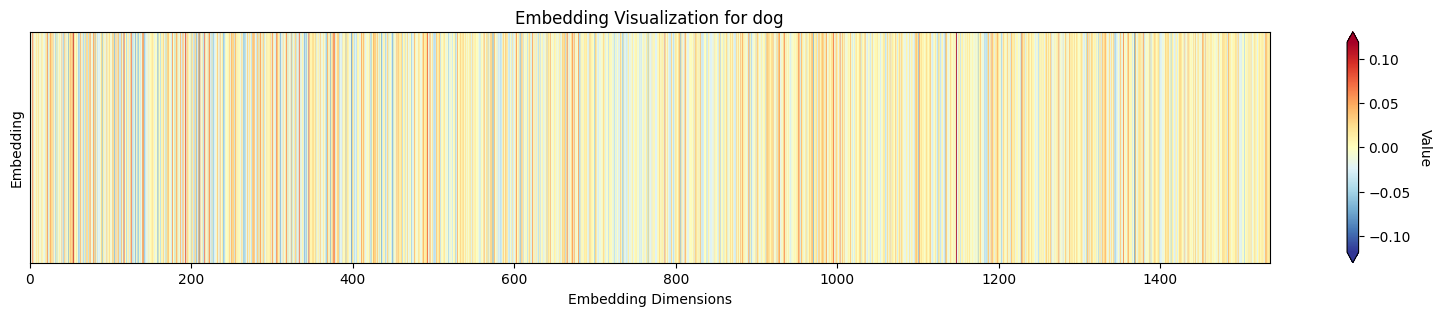

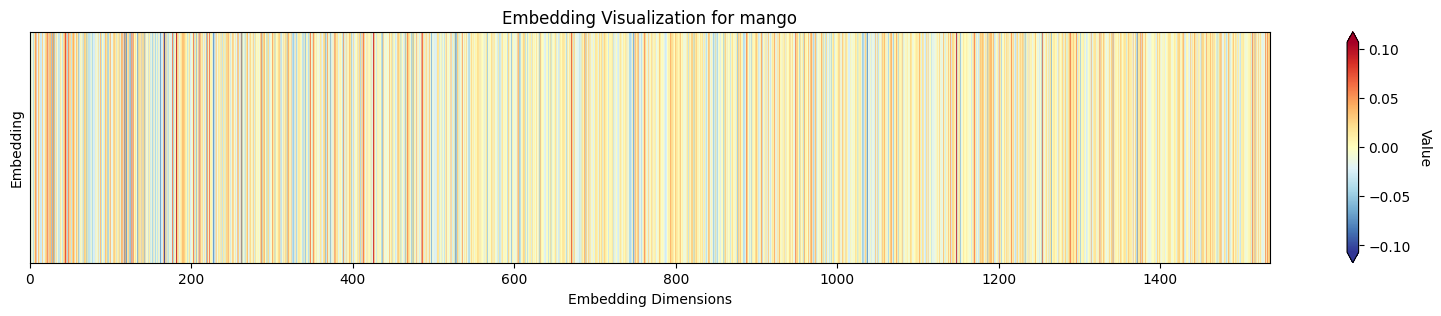

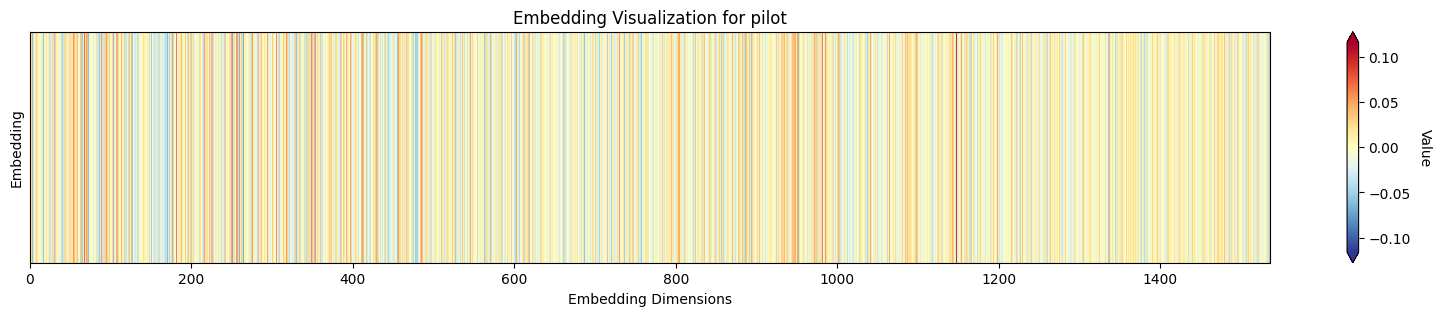

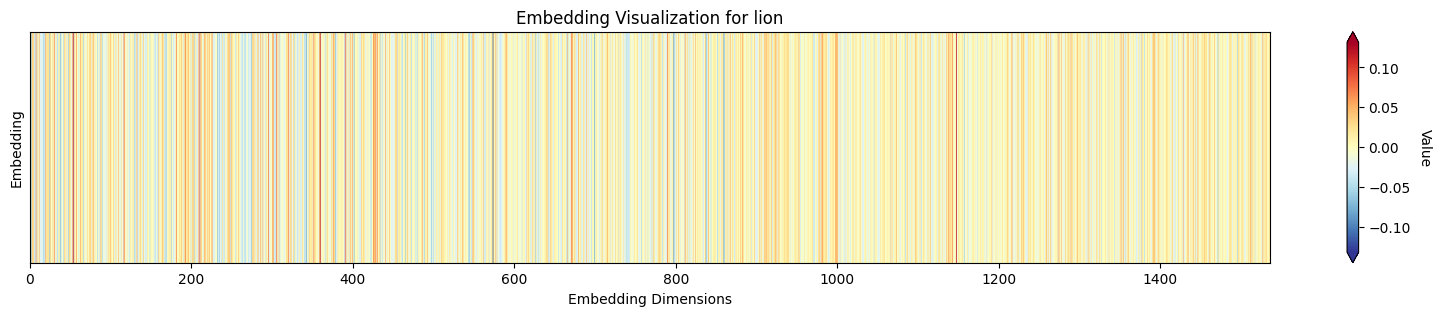

In [20]:
def visualize_embedding(embedding, title="Embedding Visualization"):
    # Reshape the embedding to a 2D array
    embedding_2d = np.array(embedding).reshape(1, -1)
    
    # Create a diverging colormap centered at zero
    cmap = plt.cm.RdYlBu_r
    vmax = max(abs(np.min(embedding_2d)), abs(np.max(embedding_2d)))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=(20, 3))
    im = ax.imshow(embedding_2d, aspect='auto', cmap=cmap, norm=norm)
    
    # Set title and labels
    plt.title(title)
    plt.xlabel("Embedding Dimensions")
    plt.ylabel("Embedding")
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, extend='both')
    cbar.set_label('Value', rotation=270, labelpad=15)
    
    # Remove y-axis ticks
    ax.set_yticks([])
    
    # Show every 200th tick on x-axis
    ax.set_xticks(range(0, len(embedding), 200))
    ax.set_xticklabels(range(0, len(embedding), 200))

    plt.show()

visualize_embedding(get_embedding("dog", df), "Embedding Visualization for dog")
visualize_embedding(get_embedding("mango", df), "Embedding Visualization for mango")
visualize_embedding(get_embedding("pilot", df), "Embedding Visualization for pilot")
visualize_embedding(get_embedding("lion", df), "Embedding Visualization for lion")

This visualization shows the value of all 1536 dimensions in the word embedding as a color scale

### 2D Representation
With 1536-dimensional embeddings, it's impossible to directly visualize the data, so introducing the t-distributed Stochastic Neighbor Embedding model to help! t-SNE is a machine learning algorithm used for dimensionality reduction that will help us reduce this to 2D or 3D, allowing us to plot and observe patterns, clusters, or relationships in our embedding space. It is designed to preserve the relationships between data points while reducing dimensionality.

While we won't capture all the nuanced details of our high dimension space, we can see some general trends!

In [23]:
df['Category'].unique()

array(['Animal', 'Food', 'Occupation', 'Weather'], dtype=object)

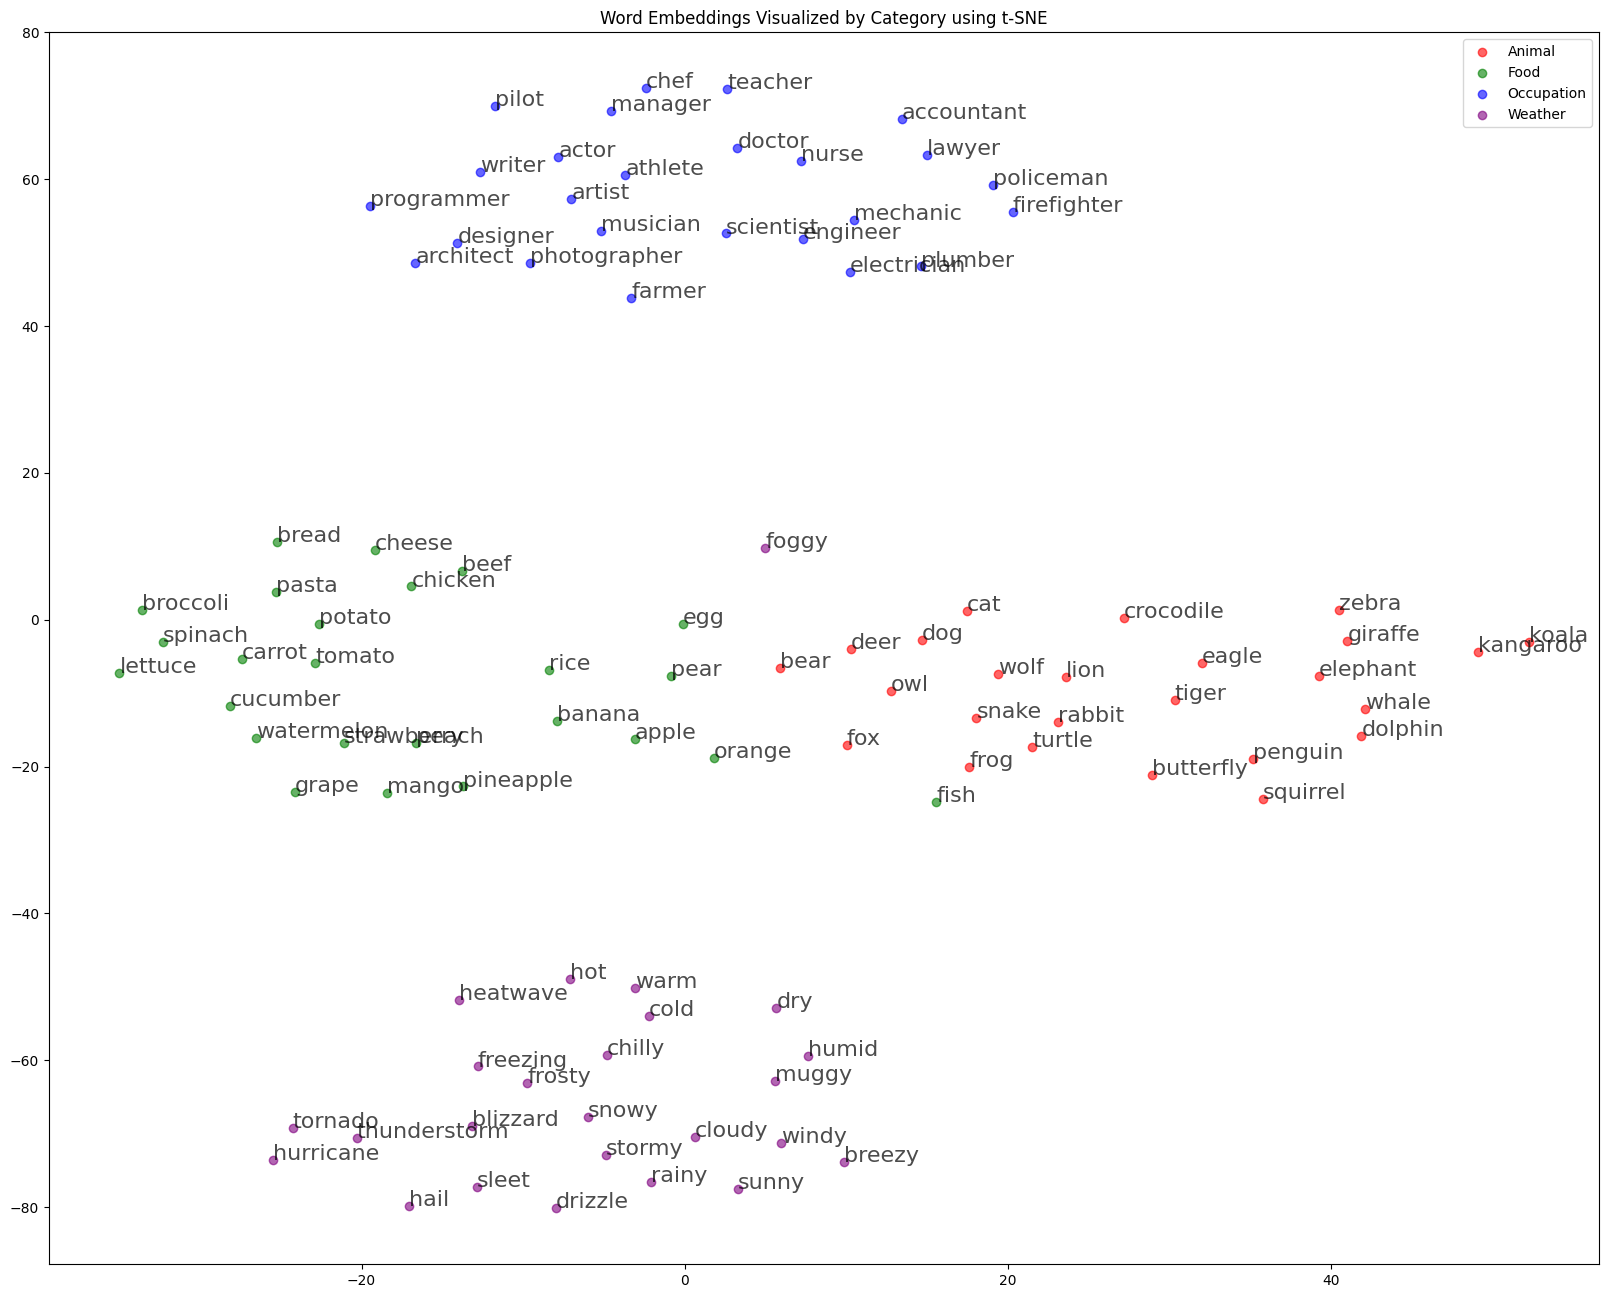

In [21]:
# Convert string representations of lists to numpy arrays
matrix = np.array(df['embedding'].apply(eval).tolist())

# Create a t-SNE model and transform the data
tsne = TSNE(n_components=2, perplexity=15, random_state=2, init='random', learning_rate=200)
vis_dims = tsne.fit_transform(matrix)

# Define colors for each category
category_colors = {
    'Animal': 'red',
    'Food': 'green',
    'Occupation': 'blue',
    'Weather': 'purple'
}

# Create the scatter plot
plt.figure(figsize=(20, 16))  # Increased figure size for better visibility
for category, color in category_colors.items():
    category_mask = df['Category'] == category
    category_data = vis_dims[category_mask]
    words = df['Word'][category_mask]
    
    plt.scatter(category_data[:, 0], category_data[:, 1], c=color, label=category, alpha=0.6)
    
    # Add labels to each point
    for i, word in enumerate(words):
        plt.annotate(word, (category_data[i, 0], category_data[i, 1]), fontsize=16, alpha=0.7)

plt.title("Word Embeddings Visualized by Category using t-SNE")
plt.legend()
plt.show()

### 3D Representation

In [25]:
# Convert string representations of lists to numpy arrays
matrix = np.array(df['embedding'].apply(eval).tolist())

# Create a t-SNE model and transform the data
tsne = TSNE(
    n_components=3,
    perplexity=10,
    n_iter=5000,
    learning_rate='auto',
    init='pca',
    random_state=2
)
vis_dims = tsne.fit_transform(matrix)

category_colors = {
    'Animal': 'red',
    'Food': 'green',
    'Occupation': 'blue',
    'Weather': 'purple'
}

# Create traces for each category
traces = []
for category, color in category_colors.items():
    category_mask = df['Category'] == category
    category_data = vis_dims[category_mask]
    words = df['Word'][category_mask]
    
    # Create hover text with only coordinates
    hovertext = [f"X: {x:.2f}, Y: {y:.2f}, Z: {z:.2f}" 
                 for x, y, z in category_data]
    
    trace = go.Scatter3d(
        x=category_data[:, 0],
        y=category_data[:, 1],
        z=category_data[:, 2],
        mode='markers+text',
        name=category,
        marker=dict(
            size=5,
            color=color,
            opacity=0.7
        ),
        text=words,
        textposition="top center",
        hovertext=hovertext,
        hoverinfo='text',
        textfont=dict(size=12)
    )
    traces.append(trace)

# Create the layout
layout = go.Layout(
    title="Word Embeddings Visualized by Category using t-SNE (3D)",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='cube',
        camera=dict(
            up=dict(x=0, y=0, z=1),
            center=dict(x=0, y=0, z=0),
            eye=dict(x=1.5, y=1.5, z=1.5)
        ),
    ),
    width=1000,  
    height=800,
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(
        x=0.9,
        y=0.9,
        traceorder="normal",
        font=dict(size=13),
        bgcolor="rgba(255, 255, 255, 0.5)"
    ),
    hovermode='closest'
)

# Create the figure and display
fig = go.Figure(data=traces, layout=layout)
init_notebook_mode(connected=True)
fig.show()